In [1]:
def hbh(x, tt):
    # y = 3 * x**2 + 2 * x - 5
    return x, 3 * x**2 + 2 * x - 5 * tt

In [2]:
z=hbh(2,3)
print(z)

(2, 1)


In [3]:
def generator_func(n):
    for i in range(n):
        yield i

print(list(generator_func(5)))

[0, 1, 2, 3, 4]


In [4]:
g=generator_func(100000)
print(next(g))
print(next(g))
print(next(g))

0
1
2


In [8]:
def greet(*names):
    print(type(names))  # names is a tuple
    for n in names:
        print(f"Hello {n}")


greet("Alice", "Bob", "Charlie")

<class 'tuple'>
Hello Alice
Hello Bob
Hello Charlie


In [13]:
def info(**kwargs):
    print(type(kwargs))  # kwargs is a dict
    for k, v in kwargs.items():
        print(f"{k}={v}")

info(name="Alice", age=25, city="Toronto")

<class 'dict'>
name=Alice
age=25
city=Toronto


In [27]:
new_map = map(lambda x, y: x * y, [1, 2, 3, 4, 5], [1, 1, 1, 1, 1])
display(list(new_map))

[1, 2, 3, 4, 5]

In [20]:
def factorial(n):
    if n in [0, 1]:
        return 1
    else:
        return n * factorial(n - 1)

6

In [23]:
factorial(5)

120

Min: -6.67
Max: 5.79
Mean: 0.09
Standard Deviation: 1.97
Q1: -1.2
Q2: 0.06
Q3: 1.46
IQR: 2.66
Outliers:
Position: 130, Value: 5.79
Position: 142, Value: 5.72
Position: 187, Value: -5.47
Position: 319, Value: -6.67
Position: 588, Value: -5.41
Position: 613, Value: -5.35
Position: 626, Value: 5.79
Position: 652, Value: -5.93
Position: 773, Value: -5.88


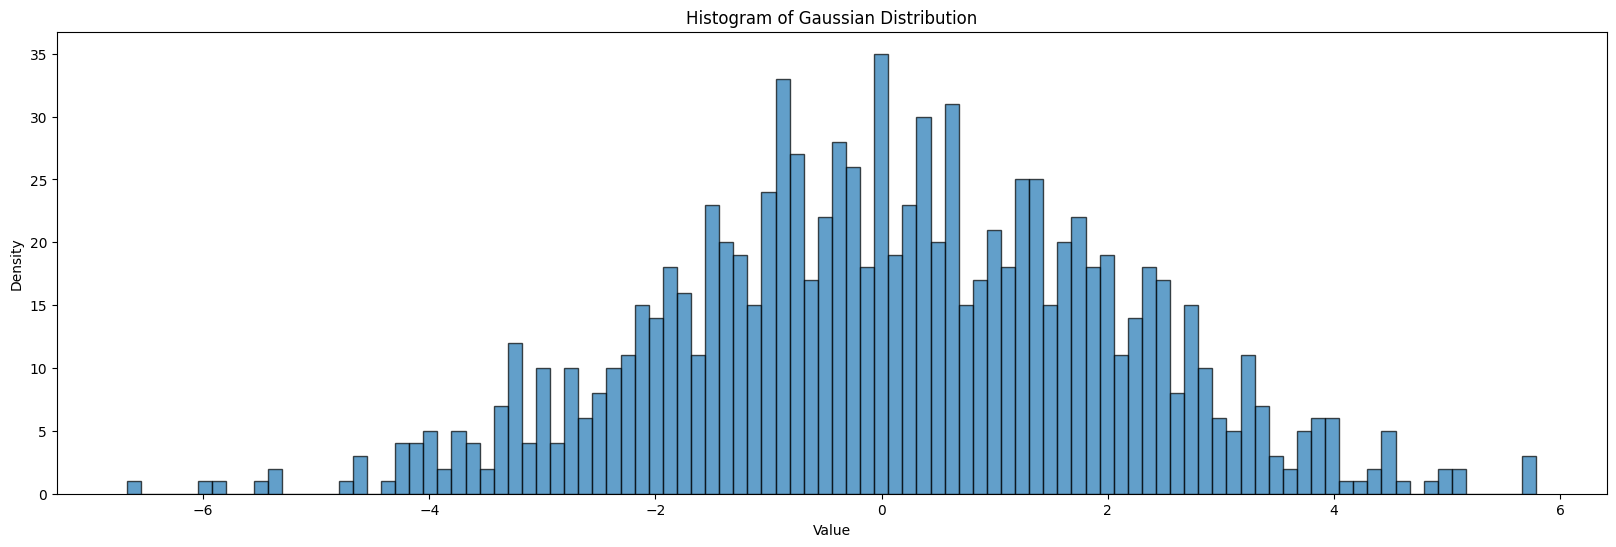

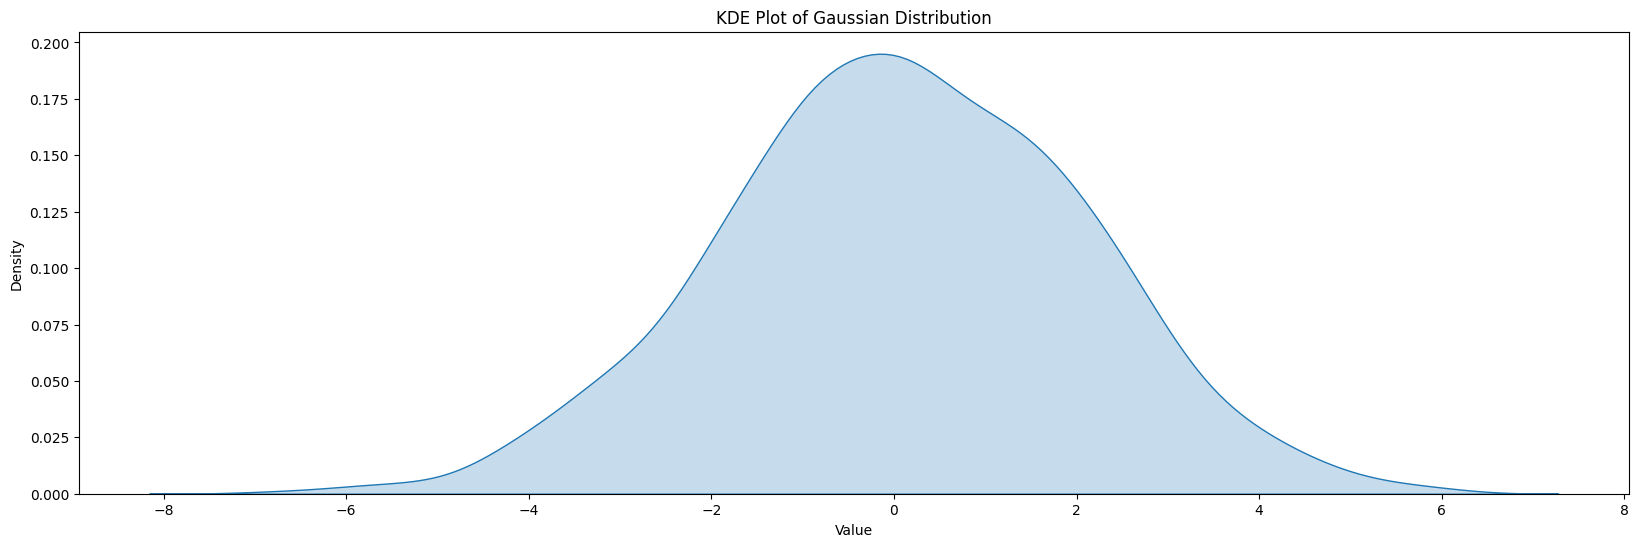

None


In [ ]:
# Question 1: Write a function to input a number N (N >500) and two more numbers (mean,std)
# and do the following things:
# A. Generate an array with N numbers with two decimals following Gauss Distribution(mean, std)
# B. Print the statistics information : min, max, mean, standard deviation, Q1, Q2, Q3, IQR
# C. If we have a rule : a outlier of list is a number are not in the range (Q1 - 1.5*IQR, Q3 + 1.5*IQR).
#    print all the outlier number and its position.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def print_statistics(array):
    min_val = np.min(array).round(2)
    max_val = np.max(array).round(2)
    mean_val = np.mean(array).round(2)
    std_val = np.std(array).round(2)
    q1 = np.percentile(array, 25).round(2)
    q2 = np.percentile(array, 50).round(2)
    q3 = np.percentile(array, 75).round(2)
    iqr = q3 - q1

    print(f"Min: {min_val}")
    print(f"Max: {max_val}")
    print(f"Mean: {mean_val}")
    print(f"Standard Deviation: {std_val}")
    print(f"Q1: {q1}")
    print(f"Q2: {q2}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")

    # Identify and print outliers
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = [
        (index + 1, value)
        for index, value in enumerate(array)
        if value < lower_bound or value > upper_bound
    ]

    print("Outliers:")
    for pos, val in outliers:
        print(f"Position: {pos}, Value: {val}")


def gauss_dist(mean, std, n):
    # Generate N numbers following a Gaussian distribution
    gaussian_array = np.random.normal(mean, std, n)
    # Round the numbers to two decimal places
    gaussian_array = np.round(gaussian_array, 2)

    print_statistics(gaussian_array)

    plt.figure(figsize=(20, 6))
    plt.hist(gaussian_array, edgecolor="black", alpha=0.7, bins=100)
    plt.title("Histogram of Gaussian Distribution")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.show()

    plt.figure(figsize=(20, 6))
    sns.kdeplot(gaussian_array, fill=True)
    plt.title("KDE Plot of Gaussian Distribution")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.show()


print(gauss_dist(0, 2, 1000))